In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading Dataset

In [18]:
df = pd.read_csv('../data/dataset.csv')
print("First 5 rows:")
print(df.head())


First 5 rows:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


## Data Preprocessing


In [19]:
#Converting yes/no into 1/0
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB
None


## Correlation Analysis


In [20]:
correlation = df.corr()

print("\nCorrelation with Performance Index:")
print(correlation["Performance Index"].sort_values(ascending=False))



Correlation with Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64


## Visualization 

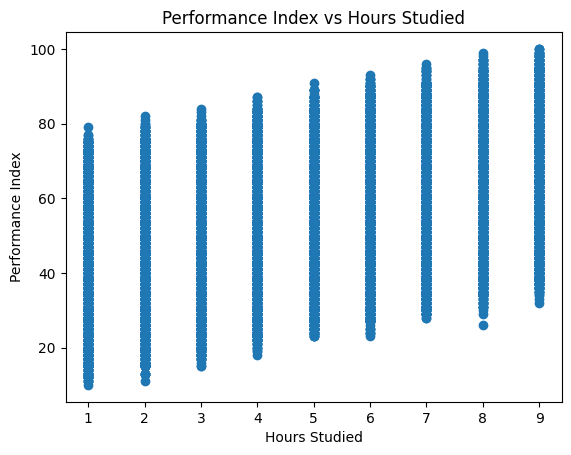

In [21]:
#Hours studied vs Performance Index
plt.figure()
plt.scatter(df["Hours Studied"], df["Performance Index"])
plt.title("Performance Index vs Hours Studied")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()


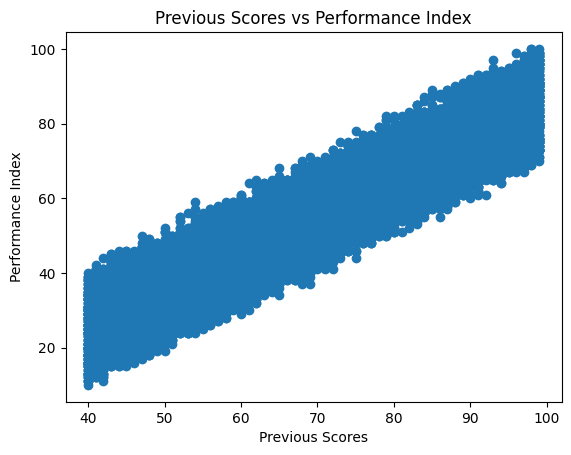

In [22]:
#Previous Scores vs Performance Index
plt.figure()
plt.scatter(df["Previous Scores"], df["Performance Index"])
plt.title("Previous Scores vs Performance Index")
plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")
plt.show()

## Linear Regression Model

In [23]:
X = df[["Hours Studied",
        "Previous Scores",
        "Sleep Hours",
        "Extracurricular Activities",
        "Sample Question Papers Practiced"]].values

y = df["Performance Index"].values

x = np.c_[np.ones(X.shape[0]), X]

#Applying Noraml Equation
theta = np.linalg.inv(x.T @ x) @ x.T @ y

print("\nModel coefficients:")
print(theta)

print("Theta shape:", theta.shape)


Model coefficients:
[-34.07558809   2.85298205   1.01843419   0.48055975   0.61289758
   0.19380214]
Theta shape: (6,)


## Prediction Function

In [24]:
def predict_performance(hours_studied, prev_scores, sleep, papers, extra):
    extra = 1 if extra.lower() == "yes" else 0
    
    input_data = np.array([1, hours_studied, prev_scores, sleep, papers, extra])
    
    print("Input shape:", input_data.shape)
    print("Theta shape:", theta.shape)
    
    print("Input data:", input_data)
    
    prediction = input_data @ theta
    return round(prediction, 2)


## Performance Category System

In [25]:
def grade(performance_index):
    if performance_index >= 90:
        return "Excellent"
    elif performance_index >= 80:
        return "Good"
    elif performance_index >= 70:
        return "Average"
    elif performance_index >= 60:
        return "Below Average"
    elif performance_index >= 50:
        return "Needs Improvement"
    elif performance_index >= 40:
        return "Poor"
    elif performance_index >= 30:
        return "Very Poor"
    else:
        return "Fail"
    
    # Score Range | Grade  
               
#90–100------Excellent         
#0–89--------Good              
#70–79-------Average           
#60–69-------Below Average     
#50–59-------Needs Improvement 
#40–49-------Poor              
#30–39-------Very Poor         
#Below 30----Fail              


## Test the Analyzer

In [26]:
def test_by_index(index):
    
    row = df.iloc[index]
    
    hours = row["Hours Studied"]
    prev = row["Previous Scores"]
    sleep = row["Sleep Hours"]
    papers = row["Sample Question Papers Practiced"]
    extra = row["Extracurricular Activities"] # If YES then 1 or If NO then 0.
    
    pred = predict_performance(hours, prev, sleep, papers, "Yes" if extra == 1 else "No")
    
    actual = row["Performance Index"]
    
    print("Student Index:", index)
    print("Actual Performance:", actual)
    print("Predicted Performance:", round(pred,2))
    print("Grade:", grade(pred))

test_by_index(10)

Input shape: (6,)
Theta shape: (6,)
Input data: [ 1.  8. 91.  4.  5.  0.]
Student Index: 10
Actual Performance: 84.0
Predicted Performance: 86.41
Grade: Good


## Model Accuracy

In [27]:
# predict all values.
y_pred = x @ theta

#calculate R^2 score 
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("\nModel Score:", round(r2, 4))




Model Score: 0.9888


In [28]:
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
5,3,78,0,9,6,61.0
6,7,73,1,5,6,63.0
7,8,45,1,4,6,42.0
8,5,77,0,8,2,61.0
9,4,89,0,4,0,69.0
